# RSI(3) Loss Profiler
# Regime Filter: Close > 89-EMA
# Setup: RSI(3) crossing above 30
# Exits: +5% TP, -3% SL, 8 Days Max Hold
# Profiling: EMA(21), RSI(14), ATR(14) %, RSI(8) Volatility

In [1]:
# 1. Imports and Setup
import pandas as pd
import numpy as np
import os
import glob
import random
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML
import warnings

warnings.filterwarnings('ignore')
display(HTML("<style>.container { width:100% !important; }</style>"))
sns.set_theme(style="darkgrid")

DATA_DIR = r'D:\0dot1_Aug_2016_master\data\mstock_mtf_daily_data'


In [2]:
# 2. Data Loading & Indicator Calculations
def calc_rsi(series, period):
    delta = series.diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()
    rs = gain / loss
    return 100 - (100 / (1 + rs))

def calc_atr(df, period):
    high_low = df['High'] - df['Low']
    high_close = np.abs(df['High'] - df['Close'].shift())
    low_close = np.abs(df['Low'] - df['Close'].shift())
    ranges = pd.concat([high_low, high_close, low_close], axis=1)
    true_range = np.max(ranges, axis=1)
    return true_range.rolling(window=period).mean()

all_data = []
files = glob.glob(os.path.join(DATA_DIR, '*.csv'))
random.seed(42) 
random.shuffle(files)

loaded = 0
for file_path in files:
    if loaded >= 50: 
        break
    symbol = os.path.basename(file_path).replace('.csv', '')
    try:
        df = pd.read_csv(file_path).dropna(subset=['Close'])
        df['Date'] = pd.to_datetime(df['Date'])
        df = df.sort_values('Date').reset_index(drop=True)
        
        if len(df) < 300: 
            continue
            
        latest_price = df['Close'].iloc[-1]
        if not (90 <= latest_price <= 600):
            continue
            
        # Core Logic
        df['EMA_89'] = df['Close'].ewm(span=89, adjust=False).mean()
        df['RSI_3'] = calc_rsi(df['Close'], 3)
        df['Setup_Signal'] = (df['Close'] > df['EMA_89']) & (df['RSI_3'] >= 30) & (df['RSI_3'].shift(1) < 30)
        
        # Profiler Metrics
        df['EMA_21'] = df['Close'].ewm(span=21, adjust=False).mean()
        df['RSI_14'] = calc_rsi(df['Close'], 14)
        
        # ATR as a % of closing price
        atr_14 = calc_atr(df, 14)
        df['ATR_14_Pct'] = (atr_14 / df['Close']) * 100
        
        # RSI 8 Volatility (Average absolute change over 8 days)
        df['RSI_8'] = calc_rsi(df['Close'], 8)
        df['RSI_8_Volatility'] = np.abs(df['RSI_8'].diff()).rolling(window=8).mean()
        
        # Keep recent 2 years for backtest
        df = df.tail(500).reset_index(drop=True)
        
        df['Symbol'] = symbol
        all_data.append(df)
        loaded += 1
    except Exception as e:
        pass

data = pd.concat(all_data, ignore_index=True)
print(f"Loaded and calculated {len(data['Symbol'].unique())} stocks.")


Loaded and calculated 50 stocks.


In [3]:
# 3. Backtesting Engine
trades = []

for symbol in data['Symbol'].unique():
    df = data[data['Symbol'] == symbol].reset_index(drop=True)
    
    in_trade = False
    entry_price = 0
    entry_date = None
    days_held = 0
    profiler_data = {}
    
    for i, row in df.iterrows():
        if pd.isna(row['EMA_89']):
            continue
            
        if in_trade:
            days_held += 1
            exit_triggered = False
            exit_reason = ""
            
            profit_pct = (row['Close'] - entry_price) / entry_price
            
            if profit_pct >= 0.05:
                exit_triggered = True
                exit_reason = "Take Profit (+5%)"
            elif profit_pct <= -0.03:
                exit_triggered = True
                exit_reason = "Stop Loss (-3%)"
            elif days_held >= 8:
                exit_triggered = True
                exit_reason = "Time Stop (8 Days)"
            
            if exit_triggered:
                trade_record = {
                    'Symbol': symbol,
                    'Entry_Date': entry_date,
                    'Exit_Date': row['Date'],
                    'Profit_Pct': profit_pct * 100,
                    'Reason': exit_reason,
                    'Result': 'Win' if profit_pct > 0 else 'Loss'
                }
                trade_record.update(profiler_data)
                trades.append(trade_record)
                in_trade = False
                days_held = 0
                
        if not in_trade and row['Setup_Signal']:
            in_trade = True
            entry_price = row['Close']
            entry_date = row['Date']
            
            # Snap Profiler Data on Entry
            profiler_data = {
                'Entry_Close_Vs_EMA21_Pct': ((row['Close'] - row['EMA_21']) / row['EMA_21']) * 100,
                'Entry_RSI_14': row['RSI_14'],
                'Entry_ATR_14_Pct': row['ATR_14_Pct'],
                'Entry_RSI_8_Vol': row['RSI_8_Volatility']
            }

trades_df = pd.DataFrame(trades)
print(f"Backtest Complete. Found {len(trades_df)} total trades.")


Backtest Complete. Found 911 total trades.


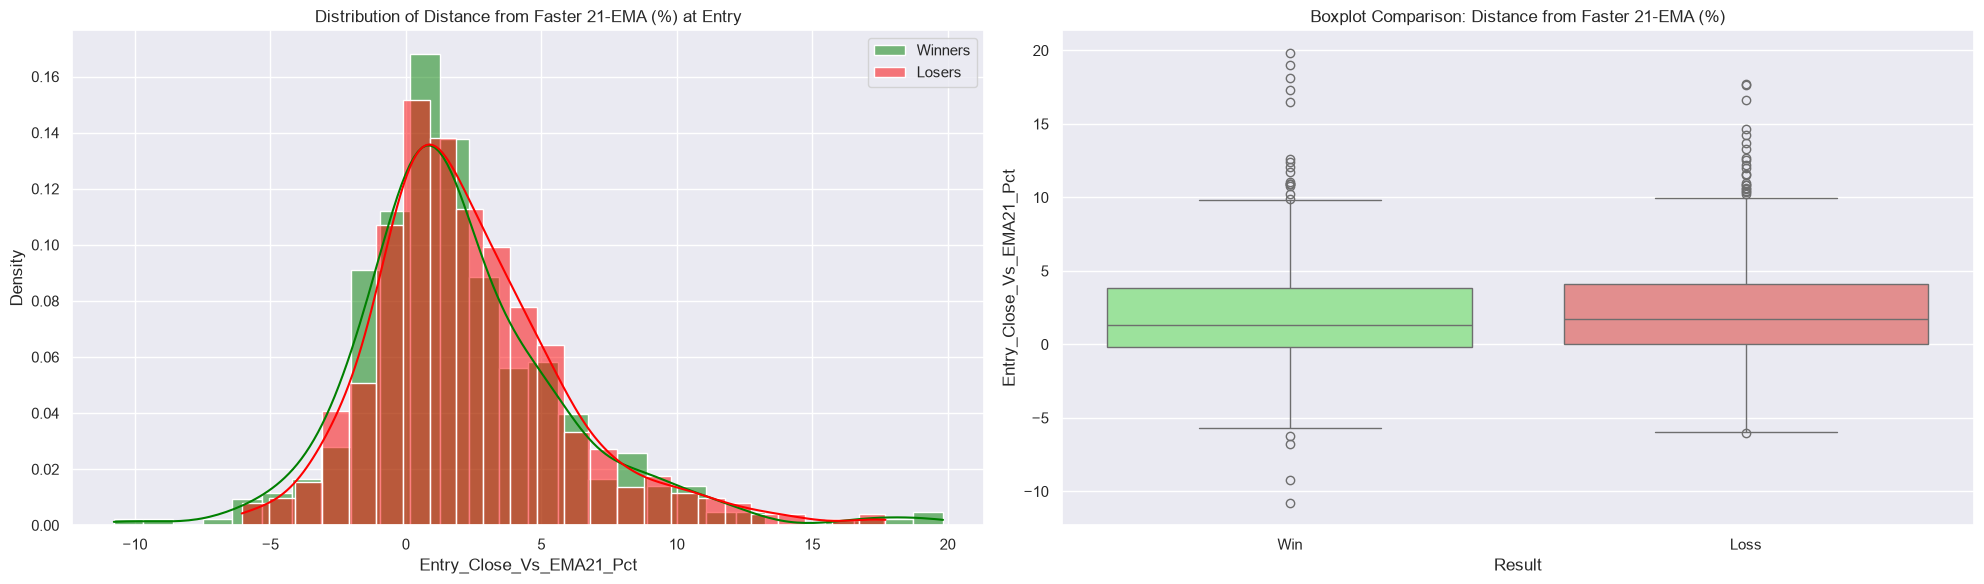

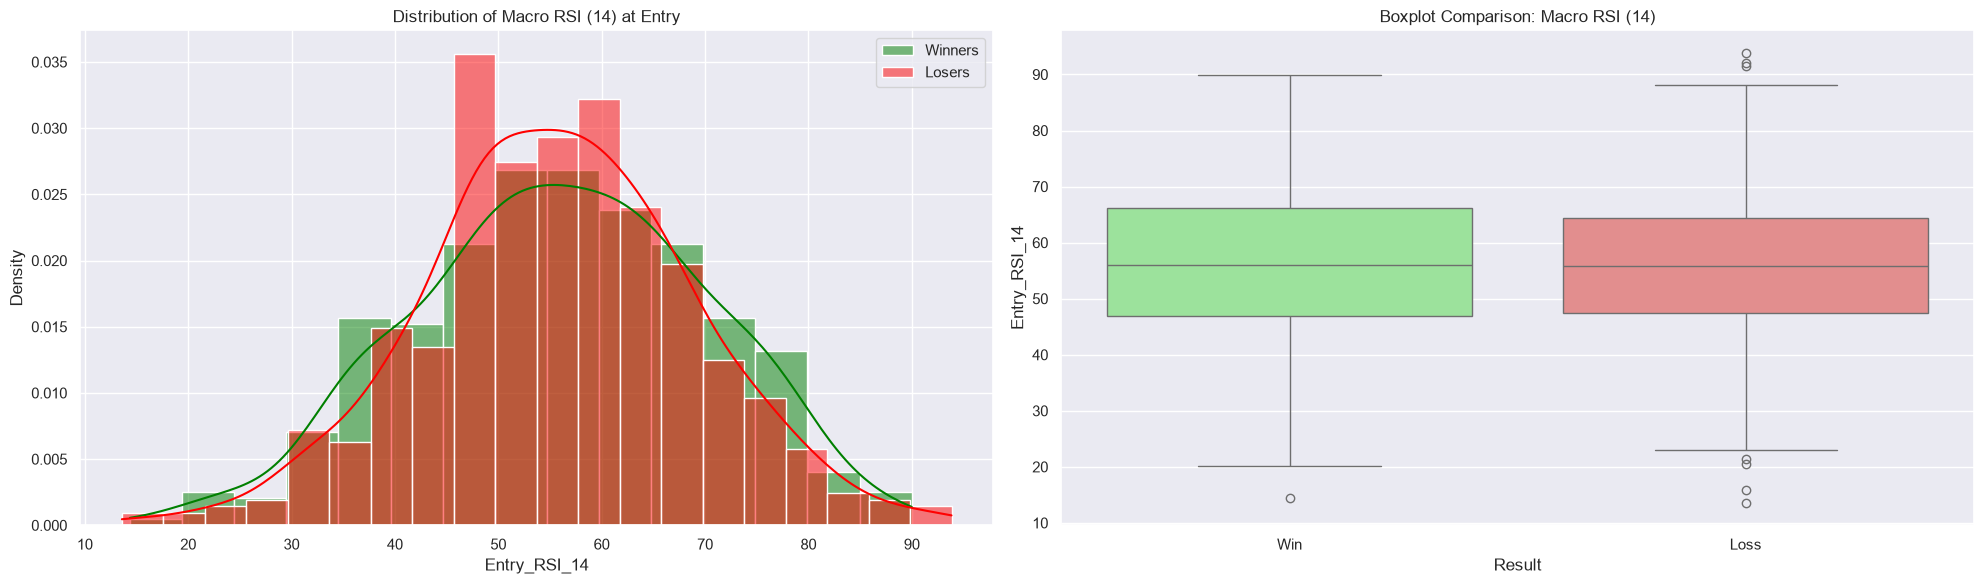

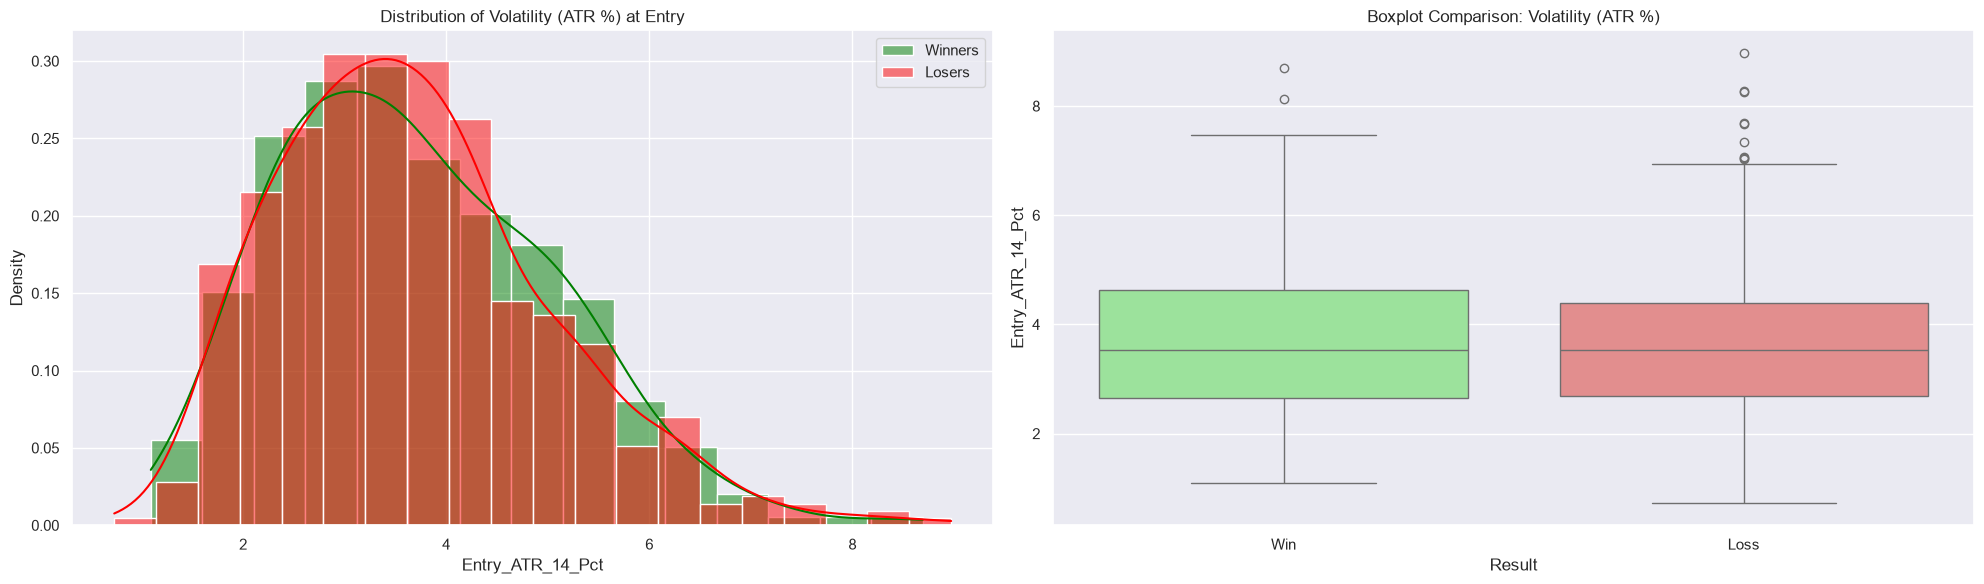

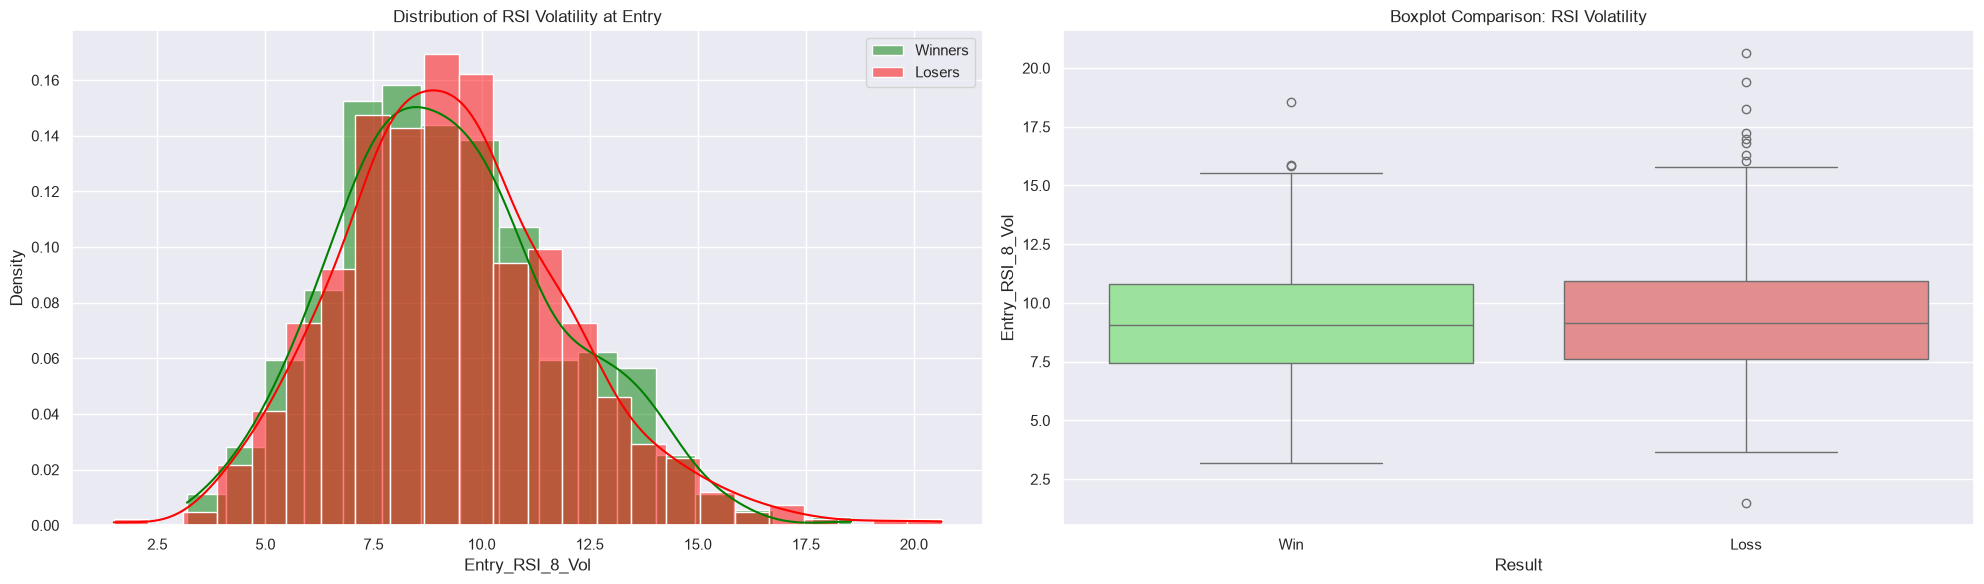

In [4]:
# 4. Loss Profiler Analysis
if len(trades_df) > 0:
    winners = trades_df[trades_df['Result'] == 'Win']
    losers = trades_df[trades_df['Result'] == 'Loss']
    
    html = f'''
    <h1 style="color: #2e6c80;">Loss Profiler Results</h1>
    <p>We captured {len(trades_df)} trades ({len(winners)} Wins, {len(losers)} Losses). 
    Below is a mathematical profile of what was happening at the exact moment those trades were opened.</p>
    '''
    display(HTML(html))
    
    metrics = ['Entry_Close_Vs_EMA21_Pct', 'Entry_RSI_14', 'Entry_ATR_14_Pct', 'Entry_RSI_8_Vol']
    metric_names = ['Distance from Faster 21-EMA (%)', 'Macro RSI (14)', 'Volatility (ATR %)', 'RSI Volatility']
    
    for metric, name in zip(metrics, metric_names):
        fig, axes = plt.subplots(1, 2, figsize=(20, 6))
        
        # Histograms
        sns.histplot(winners[metric].dropna(), color='green', label='Winners', ax=axes[0], alpha=0.5, stat='density', kde=True)
        sns.histplot(losers[metric].dropna(), color='red', label='Losers', ax=axes[0], alpha=0.5, stat='density', kde=True)
        axes[0].set_title(f"Distribution of {name} at Entry")
        axes[0].legend()
        
        # Boxplots
        sns.boxplot(data=trades_df, x='Result', y=metric, palette={'Win':'lightgreen', 'Loss':'lightcoral'}, ax=axes[1])
        axes[1].set_title(f"Boxplot Comparison: {name}")
        
        plt.tight_layout()
        plt.show()
        
        # Print Medians
        win_med = winners[metric].median()
        los_med = losers[metric].median()
        display(HTML(f"<b>Median {name}:</b> Winners = {win_med:.2f} | Losers = {los_med:.2f}"))
        display(HTML("<hr>"))
        
else:
    print("No trades found matching criteria.")
